In [1]:
%load_ext jupyter_tikz
%load_ext watermark


In [2]:
import hashlib
import re
import xml.etree.ElementTree as xml_etree


import dendropy as dp
from IPython.display import display, HTML
from hstrat import _auxiliary_lib as hstrat_aux
import matplotlib as mpl
from matplotlib import pyplot as plt
import polars as pl
from slugify import slugify
import svgpath2mpl
from teeplot import teeplot as tp

from pylib._seed_global_rngs import seed_global_rngs


Covasim 3.1.6 (2024-01-28) — © 2020-2024 by IDM


In [3]:
%watermark -diwmuv -iv


Last updated: 2025-10-25T04:26:06.467689+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1036-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

re         : 2.2.1
teeplot    : 1.4.2
dendropy   : 5.0.7
matplotlib : 3.10.0
hstrat     : 1.20.16
polars     : 1.29.0
svgpath2mpl: 1.0.0

Watermark: 2.4.3



In [4]:
teeplot_subdir = "2025-06-03-vanilla-treeviz-dendropy"
teeplot_subdir


'2025-06-03-vanilla-treeviz-dendropy'

In [5]:
seed_global_rngs(1)


## Get Data


In [6]:
url = "https://osf.io/r8skg/download"
tmp_path = f"/tmp/{teeplot_subdir}.pqt"

print(f"Downloading data from {url}")

pl.scan_parquet(
    url,
    low_memory=True,
    retries=5,
).sink_parquet(tmp_path)
print("done!")


done!


In [7]:
df = pl.scan_parquet(
    tmp_path,
    low_memory=True,
    retries=5,
)
schema = df.collect_schema()


In [8]:
fil = (
    df.filter(
        pl.col("trt_hsurf_bits").eq(0),
    )
    .filter(
        pl.col("replicate_uuid").eq(
            pl.col("replicate_uuid").first().over("trt_name"),
        )
    )
    .select(
        pl.exclude([k for k, v in schema.items() if v == pl.String]),
    )
    .collect()
)


In [9]:
def display_tikz_plot_mpl(
    tree: dp.Tree, *args: list, **kwargs: dict
) -> mpl.figure.Figure:
    tikz_svg = tree.display_tikz_plot(*args, **kwargs)
    print(f"{hashlib.sha256(tikz_svg.data.encode('utf-8')).hexdigest()=}")
    print(f"{len(tikz_svg.data)=}")

    # adapted from https://nbviewer.org/github/nvictus/svgpath2mpl/blob/master/examples/homer.ipynb
    root = xml_etree.fromstring(
        tikz_svg.data.replace("rgb(0%, 0%, 0%)", "black"),
    )
    width = int(re.match(r"\d+", root.attrib["width"]).group())
    height = int(re.match(r"\d+", root.attrib["height"]).group())
    path_elems = root.findall(r".//{http://www.w3.org/2000/svg}path")

    paths = [
        svgpath2mpl.parse_path(elem.attrib["d"]) for elem in path_elems
    ]
    print(f"{len(paths)=}")

    # edgecolors = [elem.attrib.get("stroke", "none") for elem in path_elems]
    # facecolors = [elem.attrib.get("fill", "none") for elem in path_elems]
    # linewidths = [
    #     elem.attrib.get("stroke_width", 1) for elem in path_elems
    # ]
    collection = mpl.collections.PathCollection(
        paths,
        edgecolors=["black" for _elem in path_elems],
        facecolors=["none" for _elem in path_elems],
        linewidths=[1 for _elem in path_elems],
    )

    fig, ax = plt.subplots()
    ax.set_xlim([0, width])
    ax.set_ylim([height, 0])
    collection.set_transform(ax.transData)
    ax.add_artist(collection)
    return fig


## Plot Data


phylo_df['extant'].sum()=np.int64(712)
hashlib.sha256(tikz_svg.data.encode('utf-8')).hexdigest()='6ee7b60d4053381212f20962a147e0ed507e4cfc8ad5cba1d5a34766397921ef'
len(tikz_svg.data)=296974
len(paths)=963
teeplots/trt_name=sben1-3x-gneu+viz=display-tikz-plot-mpl+ext=.pdf
teeplots/trt_name=sben1-3x-gneu+viz=display-tikz-plot-mpl+ext=.png


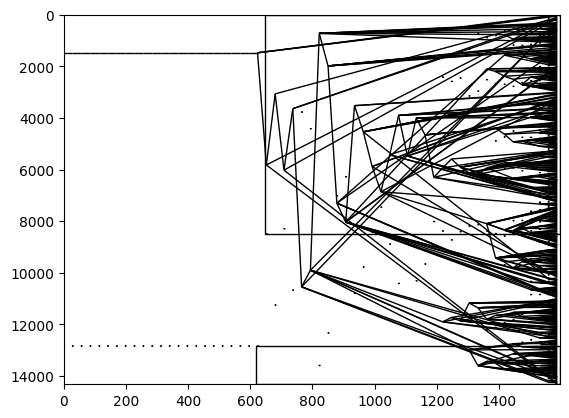

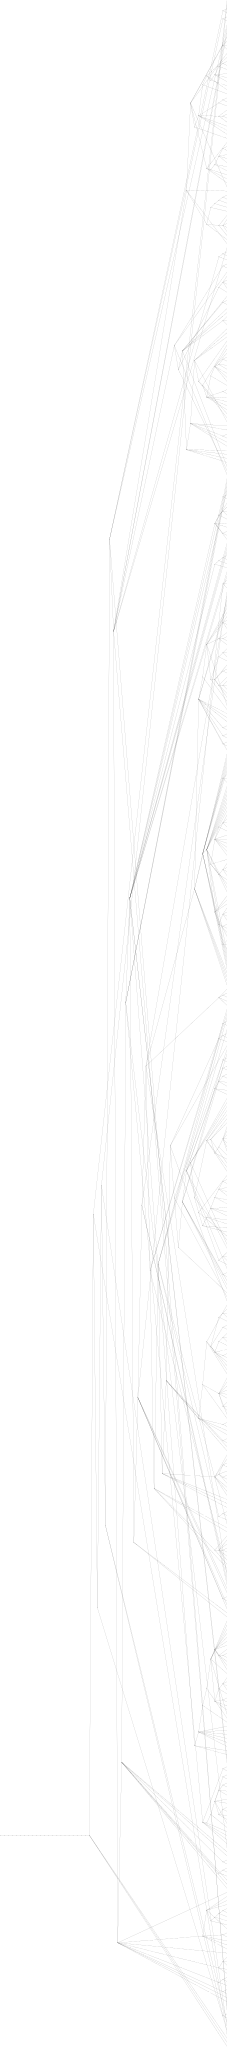

phylo_df['extant'].sum()=np.int64(591)
hashlib.sha256(tikz_svg.data.encode('utf-8')).hexdigest()='4d15a0afeebb405d248fc01e636099d23082bf9e7c13410bc0b306b201abbe0b'
len(tikz_svg.data)=245560
len(paths)=801
teeplots/trt_name=sben1-3x-gdel1-3x+viz=display-tikz-plot-mpl+ext=.pdf
teeplots/trt_name=sben1-3x-gdel1-3x+viz=display-tikz-plot-mpl+ext=.png


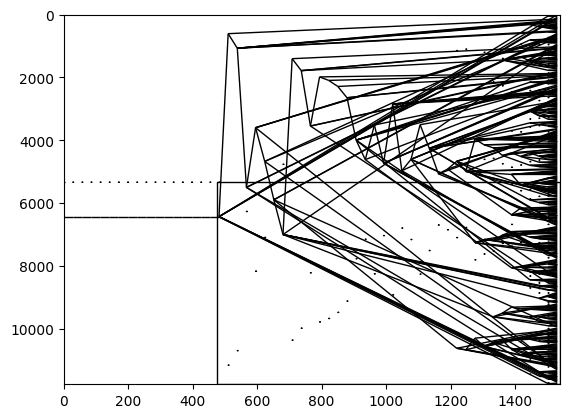

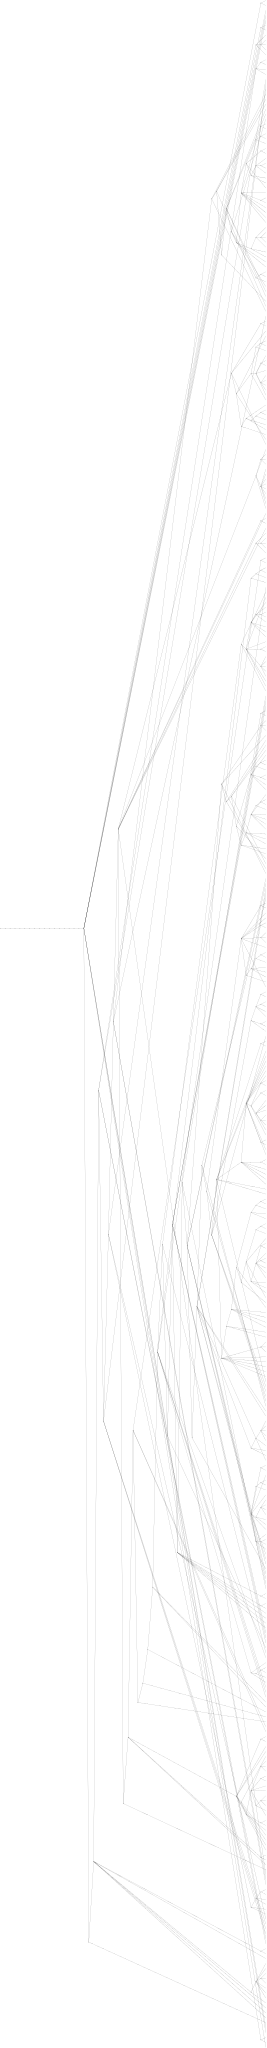

phylo_df['extant'].sum()=np.int64(680)
hashlib.sha256(tikz_svg.data.encode('utf-8')).hexdigest()='571df469e34328363c5af272be78b665a1e1c77be8e0896fbc3dbeb1397e5fff'
len(tikz_svg.data)=295889
len(paths)=958
teeplots/trt_name=sben2x-gneu+viz=display-tikz-plot-mpl+ext=.pdf
teeplots/trt_name=sben2x-gneu+viz=display-tikz-plot-mpl+ext=.png


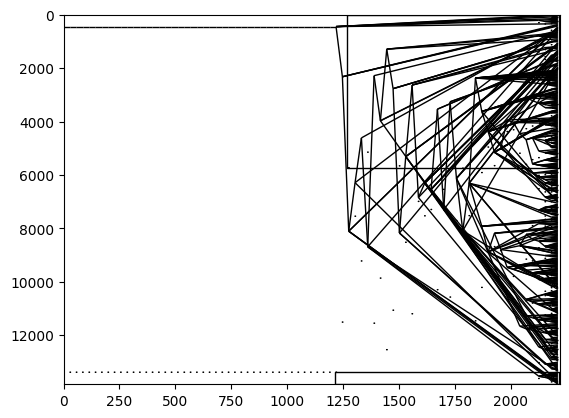

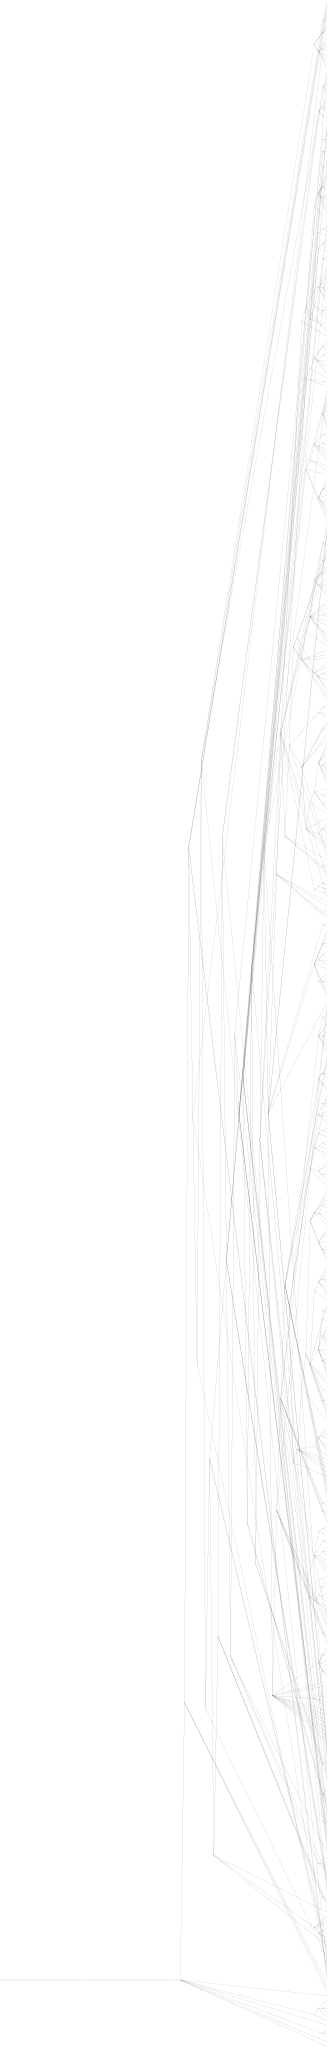

phylo_df['extant'].sum()=np.int64(653)
hashlib.sha256(tikz_svg.data.encode('utf-8')).hexdigest()='f5fb223f8e417c24105a92e87e2dc860fe70c9f92f63e449d94406b72b38b99a'
len(tikz_svg.data)=267704
len(paths)=880
teeplots/trt_name=sben1-1x-gneu+viz=display-tikz-plot-mpl+ext=.pdf
teeplots/trt_name=sben1-1x-gneu+viz=display-tikz-plot-mpl+ext=.png


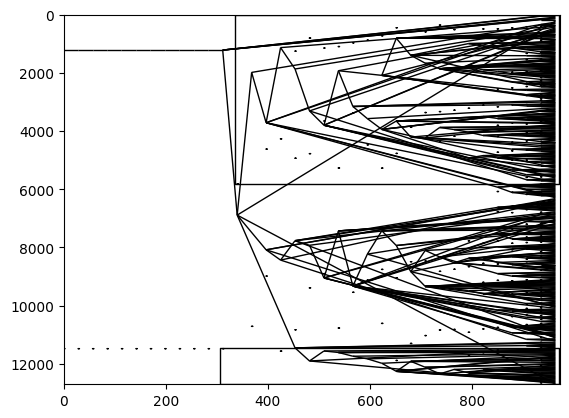

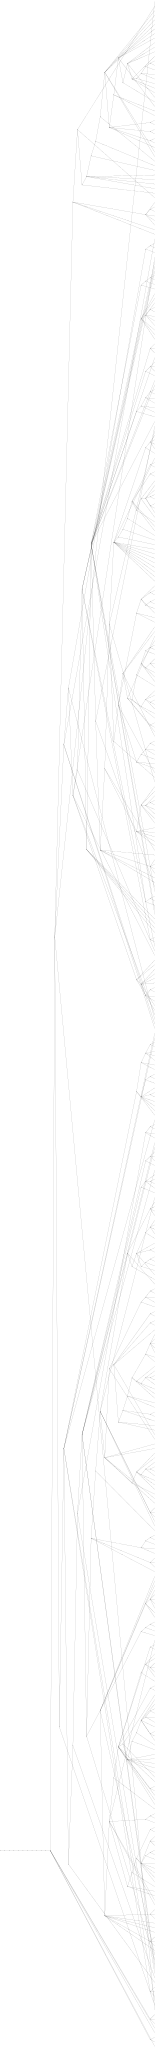

phylo_df['extant'].sum()=np.int64(670)
hashlib.sha256(tikz_svg.data.encode('utf-8')).hexdigest()='a6bd5bac1de850686cd6bd5b5d4ab50562b106a7f42b4f8077aa5e340b31cdb6'
len(tikz_svg.data)=293588
len(paths)=948
teeplots/trt_name=sben1-1x-gdel1-1x+viz=display-tikz-plot-mpl+ext=.pdf
teeplots/trt_name=sben1-1x-gdel1-1x+viz=display-tikz-plot-mpl+ext=.png


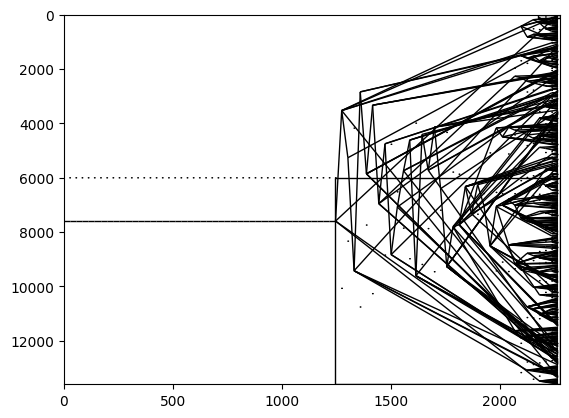

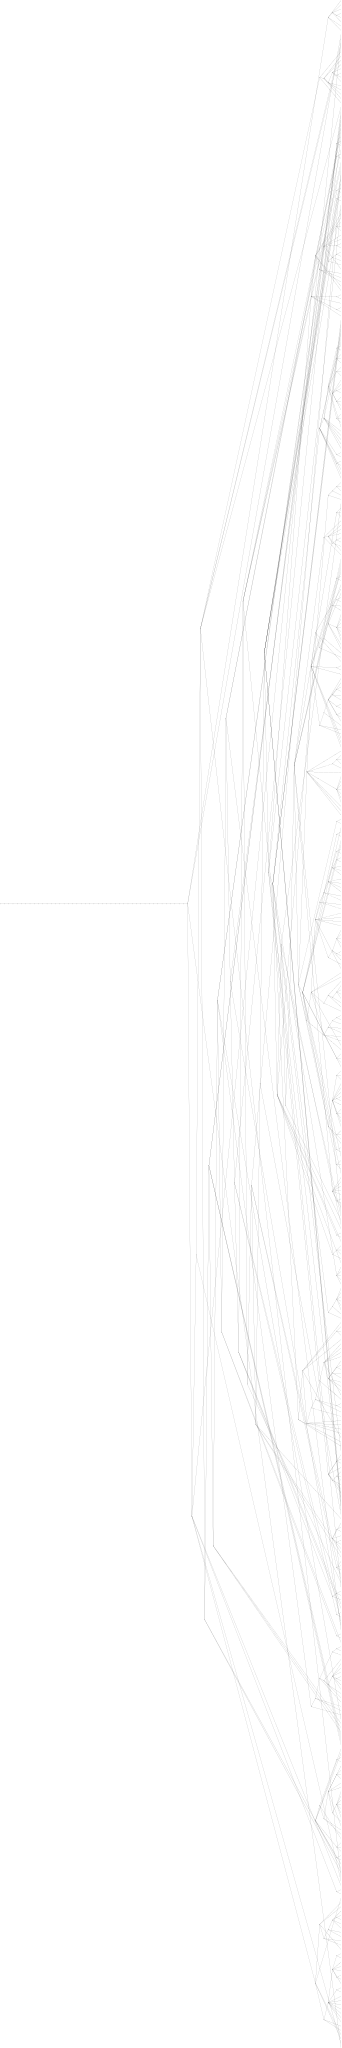

phylo_df['extant'].sum()=np.int64(572)
hashlib.sha256(tikz_svg.data.encode('utf-8')).hexdigest()='25b884eaff8571f8b7b13a6674d0c0f08bfd87d80b9f37d956d1702176864eb2'
len(tikz_svg.data)=248780
len(paths)=812
teeplots/trt_name=sben2x-gdel2x+viz=display-tikz-plot-mpl+ext=.pdf
teeplots/trt_name=sben2x-gdel2x+viz=display-tikz-plot-mpl+ext=.png


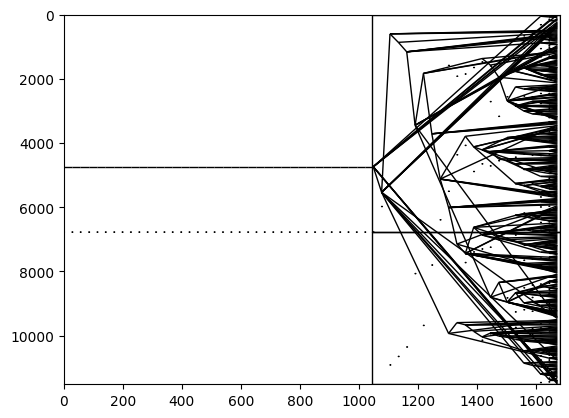

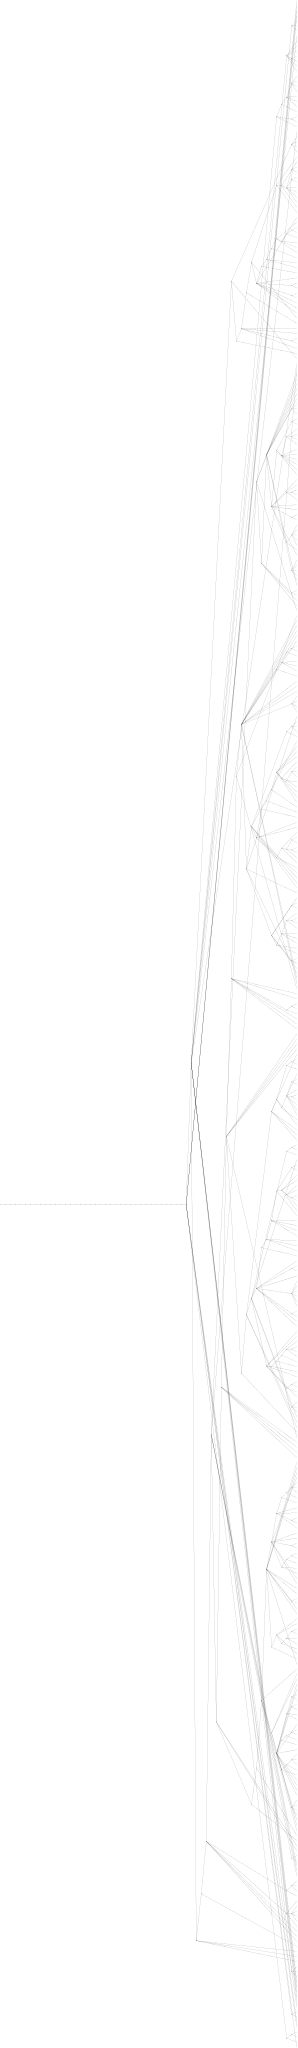

phylo_df['extant'].sum()=np.int64(590)
hashlib.sha256(tikz_svg.data.encode('utf-8')).hexdigest()='9e45a6a016f4221bab8bceeff4b434aa13ea144de9cc784b2bf21b3c38a80671'
len(tikz_svg.data)=245654
len(paths)=798
teeplots/trt_name=sneu-gneu+viz=display-tikz-plot-mpl+ext=.pdf
teeplots/trt_name=sneu-gneu+viz=display-tikz-plot-mpl+ext=.png


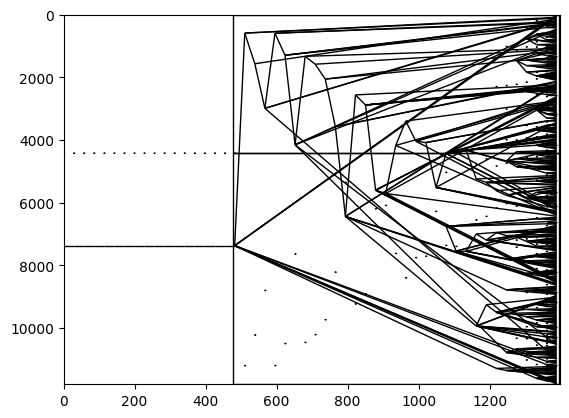

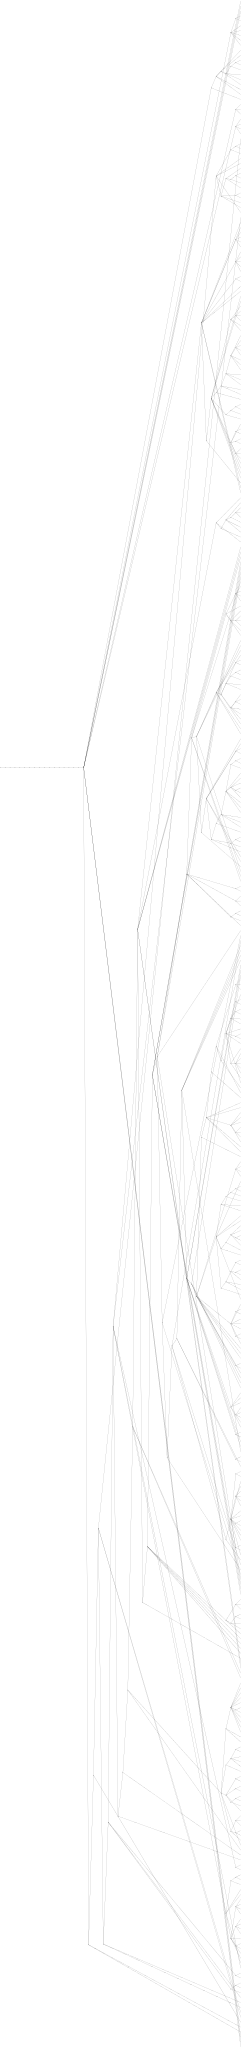

In [10]:
for (trt_name,), group in fil.group_by("trt_name"):
    display(HTML(f"<h1>{trt_name}</h1>"))

    phylo_df = group.to_pandas()

    phylo_df = hstrat_aux.alifestd_mark_num_descendants_asexual(phylo_df)
    phylo_df = hstrat_aux.alifestd_mark_clade_duration_asexual(phylo_df)
    phylo_df[
        "calc_clade_trait_count_asexual"
    ] = hstrat_aux.alifestd_calc_clade_trait_count_asexual(
        phylo_df, trait_mask=phylo_df["is_focal_defmut"].values
    )

    mask = (
        (phylo_df["origin_time"] > 50)
        & (phylo_df["num_descendants"] >= 500)
        & (phylo_df["num_descendants"] <= 750)
        & (phylo_df["calc_clade_trait_count_asexual"] > 0)
    )
    sample_idx = phylo_df.loc[mask, "id"].sample(n=1, random_state=1).item()
    sample_mask = phylo_df["id"] == sample_idx

    phylo_df = hstrat_aux.alifestd_mask_descendants_asexual(
        phylo_df,
        ancestor_mask=phylo_df["is_focal_defmut"],
    ).rename(
        columns={
            "alifestd_mask_descendants_asexual": "focal_defmut_descendant",
        },
    )

    phylo_df = hstrat_aux.alifestd_mask_descendants_asexual(
        phylo_df,
        ancestor_mask=sample_mask,
    )

    phylo_df["extant"] = phylo_df["alifestd_mask_descendants_asexual"]
    print(f"{phylo_df['extant'].sum()=}")
    phylo_df = hstrat_aux.alifestd_prune_extinct_lineages_asexual(phylo_df)

    sample_ot_min = phylo_df.loc[
        phylo_df["extant"].values, "origin_time"
    ].min()
    sample_ot_max = phylo_df.loc[
        phylo_df["extant"].values, "origin_time"
    ].max()

    newick = hstrat_aux.alifestd_as_newick_asexual(
        phylo_df,
        taxon_label="focal_defmut_descendant",
    )

    tree = dp.Tree.get(
        data=newick,
        schema="newick",
        suppress_internal_node_taxa=True,
        suppress_leaf_node_taxa=True,
    )

    # way 1, via matplotlib
    tp.tee(
        display_tikz_plot_mpl,
        tree,
        node_label_compose_fn=lambda n: "",
        teeplot_outattrs={"trt_name": slugify(trt_name)},
    )

    # way 2, pure svg
    tikz_svg = tree.display_tikz_plot(node_label_compose_fn=lambda n: "")
    tikz_svg.data = tikz_svg.data.replace(
        "<svg",
        "<svg style='background-color: white'",
    )
    display(tikz_svg)
